In [1]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, ConcatDataset
from transformers import WhisperForAudioClassification, WhisperProcessor
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, accuracy_score, classification_report, balanced_accuracy_score
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import time
from tqdm import tqdm
import librosa
import random

d:\shemo_env\shemo_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if torch.cuda.is_available():
  device = 'cuda'
else:
  device = 'cpu'

device

'cuda'

In [3]:
# Defining a function to set or change the seed for random number generation at each step.

def reset_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available:
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# whisper shemo loading

In [4]:
whisper_tiny_processor = WhisperProcessor.from_pretrained('whisper_small')

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [5]:
reset_seed(42)
emo2num = {
    'H' : 0,
    'N' : 1,
    'S' : 2,
    'A' : 3,
    'W' : 4
}

num2emo = {
    0 : 'Happy',
    1 : 'Neutral',
    2 : 'Sad',
    3 : 'Anger',
    4 : 'Wonder'
}


audios = []
sample_rates = []
emotions = []
labels = []
file_names = []
file_paths = []
features = []

pattern = r'^...(.)'

for root, folders, files in os.walk('shemo'):
    for filename in files:
        file_path = os.path.join(root, filename)
        audio_data, sr = librosa.load(file_path, sr=16000)
        
        input_features = whisper_tiny_processor(audio_data, sampling_rate=sr, return_tensors="pt").input_features
    

        match = re.search(pattern, filename)
        if match:
            char = match.group(1)
            if char in ['H', 'N', 'S', 'W', 'A']:
                audios.append(audio_data)
                sample_rates.append(sr)
                # emotion = 'H' if char == 'W' else char
                emotion = char
                label = emo2num[emotion]

                emotions.append(emotion)
                labels.append(label)
                features.append(input_features.squeeze(0))
                file_names.append(filename)
                file_paths.append(file_path)

In [6]:
reset_seed(42)
class AudioDataSet(Dataset):
    def __init__(self, features, labels, file_names=None, file_paths=None):
        self.features = features
        self.labels = labels
        self.index = list(range(len(labels)))
        self.filename = file_names
        self.filepath = file_paths


    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        # Assuming features[index] is a processed audio feature and labels[index] is the corresponding label
        sample = {
            'feature': torch.Tensor(self.features[index]),  # Convert to PyTorch tensor if not already
            'label': torch.Tensor([self.labels[index]]),  # Convert to PyTorch tensor if not already
            'name' : self.filename[index],
            'path' : self.filepath[index],
            'gender': self.filename[index][0],
            'index': self.index[index]
        }


        return sample
    

Shemo = AudioDataSet(features, labels, file_names, file_paths)


# Split the dataset into training and validation sets
trainset, valset = random_split(Shemo, [len(Shemo)-500, 500])

In [7]:
trainset_indices = list(map(lambda x: x['index'], trainset))

In [8]:
trainset[1]

{'feature': tensor([[-0.0341,  0.3568,  0.3879,  ..., -0.7407, -0.7407, -0.7407],
         [ 0.1451,  0.2130,  0.2048,  ..., -0.7407, -0.7407, -0.7407],
         [ 0.1138,  0.1652,  0.1562,  ..., -0.7407, -0.7407, -0.7407],
         ...,
         [-0.5417, -0.4786, -0.4902,  ..., -0.7407, -0.7407, -0.7407],
         [-0.6395, -0.5988, -0.5228,  ..., -0.7407, -0.7407, -0.7407],
         [-0.7407, -0.7407, -0.7357,  ..., -0.7407, -0.7407, -0.7407]]),
 'label': tensor([1.]),
 'name': 'M04N75.wav',
 'path': 'shemo\\M04N75.wav',
 'gender': 'M',
 'index': 1473}

In [9]:
audios_to_aug = [audio for (ind,audio) in enumerate(audios) if ind in trainset_indices]
audio_gender_to_aug = [name[0] for (ind,name) in enumerate(file_names) if ind in trainset_indices]
audio_emo_to_aug = [emotion for (ind,emotion) in enumerate(emotions) if ind in trainset_indices]

In [10]:
segments ={}


for emotion in ['H', 'W', 'S', 'A', 'N']:

    audiosF1 = [audio_data[:len(audio_data)//2] for (audio_data, gen, emo) in zip(audios_to_aug, audio_gender_to_aug, audio_emo_to_aug) if (gen == 'F' and emo == emotion)]
    audiosF2 = [audio_data[len(audio_data)//2:] for (audio_data, gen, emo) in zip(audios_to_aug, audio_gender_to_aug, audio_emo_to_aug) if (gen == 'F' and emo == emotion)]
    audiosM1 = [audio_data[:len(audio_data)//2] for (audio_data, gen, emo) in zip(audios_to_aug, audio_gender_to_aug, audio_emo_to_aug) if (gen == 'M' and emo == emotion)]
    audiosM2 = [audio_data[len(audio_data)//2:] for (audio_data, gen, emo) in zip(audios_to_aug, audio_gender_to_aug, audio_emo_to_aug) if (gen == 'M' and emo == emotion)]

    segments[emotion] = [(audiosF1, audiosF2), (audiosM1, audiosM2)]

In [12]:
augmented_audios = []
augmented_labels = []
augmented_emotions = []

augmentation_need = {
    'H': 9,
    'W': 9,
    'S': 4,
    'A': 1,
    'N': 1
    }

In [13]:
for category in segments:
    for gender_segments in segments[category]:
        for audio in gender_segments[0]:
            choice = random.sample(gender_segments[1], augmentation_need[category])
            for ch in choice:
                new_speech = np.concatenate((audio, ch))
                augmented_audios.append(new_speech)
                augmented_emotions.append(category)
                augmented_labels.append(emo2num[category])


In [14]:
reset_seed(42)

augmented_samplerates = []
augmeted_features = []


for audio in augmented_audios:

    input_features = whisper_tiny_processor(audio, sampling_rate=16000, return_tensors="pt").input_features

    augmented_samplerates.append(16000)
    augmeted_features.append(input_features.squeeze(0))

In [15]:
len(augmeted_features)

6493

In [16]:
augmeted_features[8]

tensor([[-0.7035, -0.5351, -0.4158,  ..., -0.7035, -0.7035, -0.7035],
        [-0.7035, -0.6157, -0.5085,  ..., -0.7035, -0.7035, -0.7035],
        [-0.7035, -0.7035, -0.5895,  ..., -0.7035, -0.7035, -0.7035],
        ...,
        [-0.7035, -0.6555, -0.6899,  ..., -0.7035, -0.7035, -0.7035],
        [-0.7035, -0.6647, -0.6822,  ..., -0.7035, -0.7035, -0.7035],
        [-0.7035, -0.7035, -0.7035,  ..., -0.7035, -0.7035, -0.7035]])

In [18]:
reset_seed(42)
Aug = AudioDataSet(augmeted_features, augmented_labels, [' ']*len(augmeted_features), [' ']*len(augmeted_features))
concatenated_dataset = ConcatDataset([trainset, Aug])

train_loader = DataLoader(concatenated_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(valset, batch_size=4, shuffle=False)

In [19]:
len(concatenated_dataset)

8955

# train and test funcs

In [20]:
reset_seed(42)
def train(model, model_name, optimizer, loss_fn, train_loader, val_loader, epochs =40, patience=4):
  training_losses = []
  valid_losses = []
  durations = []
  best_val_loss = float('inf')
  current_patience = 0

  for epoch in range(epochs):
    training_loss = []
    valid_loss = []
    start_time = time.time()

    model.train()
    for batch in tqdm(train_loader, desc=f'Epoch {epoch}/{epochs}', leave=False): # Each batch, One Iteration
      optimizer.zero_grad()
      inputs, targets = batch['feature'], batch['label'].squeeze(-1).long()
      inputs, targets = inputs.to(device), targets.to(device)
      output = model(inputs).logits
      loss = loss_fn(output, targets)
      loss.backward()
      optimizer.step()
      inputs, targets, output = inputs.to('cpu'), targets.to('cpu'), output.to('cpu') # Return tensors to cpu after each iteration

      training_loss.append(loss.data.item())
    training_loss = np.mean(training_loss)
    training_losses.append(training_loss)
    

    model.eval()
    num_correct = 0
    num_examples = 0
    for batch in tqdm(val_loader, desc=f'Epoch {epoch}/{epochs}', leave=False):
      inputs, targets = batch['feature'], batch['label'].squeeze(-1).long()
      inputs, targets = inputs.to(device), targets.to(device)
      output = model(inputs).logits
      loss = loss_fn(output, targets)
      valid_loss.append(loss.data.item())
      correct = torch.eq(torch.argmax(F.softmax(output, dim=1), dim=1), targets.view(-1))
      num_correct += torch.sum(correct).item()
      num_examples += correct.shape[0]
      inputs, targets, output = inputs.to('cpu'), targets.to('cpu'), output.to('cpu') # Return tensors to cpu after each iteration
      
    valid_loss = np.mean(valid_loss)
    valid_losses.append(valid_loss)
    end_time = time.time()
    duration = end_time - start_time
    durations.append(duration)

    print(f'Epoch: {epoch+1} finished in {duration:.2f} seconds, Training Loss: {training_loss: .2f}, Validation Loss: {valid_loss:.2f}, Validation Accuracy: {num_correct / num_examples : .2f}')

    # Check for improvement
    if valid_loss < best_val_loss:
        best_val_loss = valid_loss
        torch.save(model.state_dict(), f'{model_name}.bin') # Saving the best model because I want to use the best checkpoints of the model to test it
        current_patience = 0
    else:
        current_patience += 1

    # Early stopping logic
    if current_patience >= patience:
        print(f"Early stopping at epoch {epoch+1}. Because Validation loss increased for {patience} consecutive epochs.")
        break

  print(f"Each epoch took {np.mean(durations):.2f} seconds in average.")

  return training_losses, valid_losses

In [21]:
def test(model, loss_fn, test_loader):
  model.eval()
  test_loss = []
  labels = []
  preds = []
  for batch in test_loader:
    inputs, targets = batch['feature'], batch['label'].squeeze(-1).long()

    for target in targets:
      labels.append(target.item())
    inputs, targets = inputs.to(device), targets.to(device)
    output = model(inputs).logits
    for out in output:
      preds.append(torch.argmax(F.softmax(out, dim=0), dim=0).item())
    loss = loss_fn(output, targets)
    test_loss.append(loss.data.item())
    inputs, targets, output = inputs.to('cpu'), targets.to('cpu'), output.to('cpu') # Return tensors to cpu after each iteration


  #######################################################################################################
  accuracy_per_class = {}
  unique_classes = set(labels)
  for class_label in unique_classes:
      indices = [i for i, y in enumerate(labels) if y == class_label]
      class_accuracy = accuracy_score([labels[i] for i in indices], [preds[i] for i in indices])
      accuracy_per_class[class_label] = class_accuracy

  w_acc = sum(accuracy_per_class.values())/len(accuracy_per_class.values())
  #######################################################################################################


  test_loss = np.mean(test_loss)
  w_acc = accuracy_score(labels, preds)
  u_acc = sum(accuracy_per_class.values())/len(accuracy_per_class.values())
  precision = precision_score(labels, preds, average='weighted')
  recall = recall_score(labels, preds, average='weighted')
  f1 = f1_score(labels, preds, average='weighted')
  cm = confusion_matrix(labels, preds)
  sns.set(font_scale=1.2)  # Adjust the font scale for better readability
  sns.heatmap(cm, annot=True, fmt='g', cmap='Greens', 
              xticklabels=['Happy', 'Neutral', 'Sad', 'Anger', 'wonder'], 
              yticklabels=['Happy', 'Neutral', 'Sad', 'Anger', 'wonder'])
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()

  print(f'Testing finished with Loss: {test_loss: .2f} | U_Accuracy: {u_acc : .2f} | W_Accuracy: {w_acc : .2f} | Precision: {precision : .2f} | Recall: {recall : .2f} | f1: {f1 : .2f}')

  print("Accuracy per class:")
  for class_label, accuracy in accuracy_per_class.items():
      print(f"Class {class_label}: {accuracy}")

# tiny aug2

In [74]:
reset_seed(42)
whisper_tiny_path = 'whisper_tiny'
whisper_tiny = WhisperForAudioClassification.from_pretrained(
    whisper_tiny_path
)


for param in whisper_tiny.parameters():
    param.requires_grad = False

for param in whisper_tiny.projector.parameters():
    param.requires_grad = True

whisper_tiny.classifier = torch.nn.Linear(256, 5) # Changing the head to fit our data and problem

whisper_tiny.to(device)

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_tiny and are newly initialized: ['model.projector.weight', 'model.classifier.weight', 'model.classifier.bias', 'model.projector.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


WhisperForAudioClassification(
  (encoder): WhisperEncoder(
    (conv1): Conv1d(80, 384, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv2): Conv1d(384, 384, kernel_size=(3,), stride=(2,), padding=(1,))
    (embed_positions): Embedding(1500, 384)
    (layers): ModuleList(
      (0-3): 4 x WhisperEncoderLayer(
        (self_attn): WhisperSdpaAttention(
          (k_proj): Linear(in_features=384, out_features=384, bias=False)
          (v_proj): Linear(in_features=384, out_features=384, bias=True)
          (q_proj): Linear(in_features=384, out_features=384, bias=True)
          (out_proj): Linear(in_features=384, out_features=384, bias=True)
        )
        (self_attn_layer_norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (activation_fn): GELUActivation()
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (final_layer_norm): LayerNorm((384,), eps=1e-05, elementwise_

In [75]:
reset_seed(42)
optimizer = torch.optim.Adam(whisper_tiny.parameters(), lr=0.001)

training_losses0, valid_losses0 = train(whisper_tiny, 'whisper_tiny_augmented2', optimizer, torch.nn.CrossEntropyLoss(), train_loader, val_loader, patience=40)

Epoch: 1 finished in 89.40 seconds, Training Loss:  0.93, Validation Loss: 0.85, Validation Accuracy:  0.69


Epoch: 2 finished in 87.00 seconds, Training Loss:  0.70, Validation Loss: 0.64, Validation Accuracy:  0.77


Epoch: 3 finished in 86.35 seconds, Training Loss:  0.63, Validation Loss: 0.73, Validation Accuracy:  0.73


Epoch: 4 finished in 87.22 seconds, Training Loss:  0.59, Validation Loss: 0.62, Validation Accuracy:  0.77


Epoch: 5 finished in 86.39 seconds, Training Loss:  0.57, Validation Loss: 0.61, Validation Accuracy:  0.80


...

Epoch: 36 finished in 97.83 seconds, Training Loss:  0.38, Validation Loss: 0.48, Validation Accuracy:  0.85


Epoch: 37 finished in 87.58 seconds, Training Loss:  0.38, Validation Loss: 0.61, Validation Accuracy:  0.80


Epoch: 38 finished in 86.80 seconds, Training Loss:  0.38, Validation Loss: 0.64, Validation Accuracy:  0.78


Epoch: 39 finished in 84.95 seconds, Training Loss:  0.38, Validation Loss: 0.58, Validation Accuracy:  0.80


Epoch: 40 finished in 87.22 seconds, Training Loss:  0.37, Validation Loss: 0.54, Validation Accuracy:  0.85
Each epoch took 85.75 seconds in average.


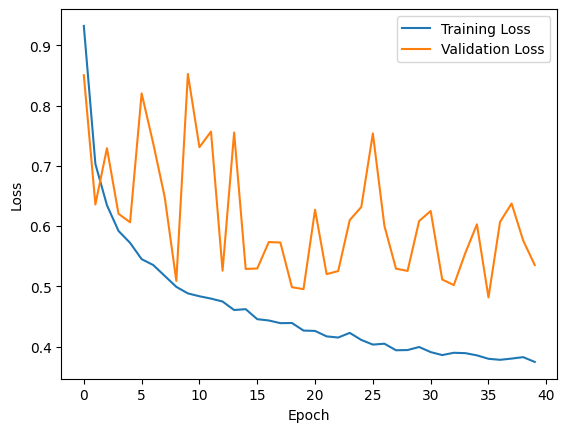

In [76]:
plt.plot(training_losses0, label='Training Loss')
plt.plot(valid_losses0, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

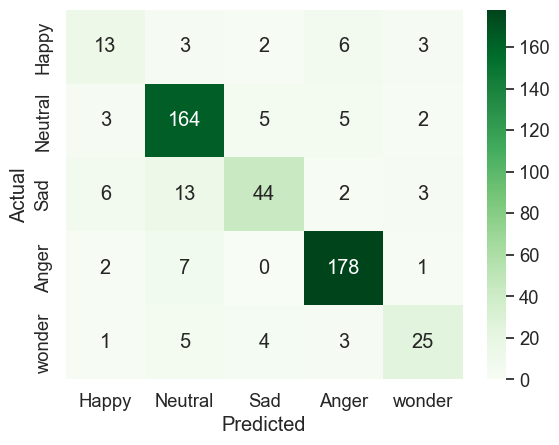

Testing finished with Loss:  0.48 | U_Accuracy:  0.73 | W_Accuracy:  0.85 | Precision:  0.84 | Recall:  0.85 | f1:  0.84
Accuracy per class:
Class 0: 0.48148148148148145
Class 1: 0.9162011173184358
Class 2: 0.6470588235294118
Class 3: 0.9468085106382979
Class 4: 0.6578947368421053


In [77]:
whisper_tiny.load_state_dict(torch.load('whisper_tiny_augmented2.bin'))
test(whisper_tiny, torch.nn.CrossEntropyLoss(), val_loader)

In [78]:
whisper_tiny.to('cpu')
del whisper_tiny

# Small Aug2

In [23]:
reset_seed(42)
whisper_small_path = 'whisper_small'
whisper_small = WhisperForAudioClassification.from_pretrained(
    whisper_small_path
)


for param in whisper_small.parameters():
    param.requires_grad = False

for param in whisper_small.projector.parameters():
    param.requires_grad = True

whisper_small.classifier = torch.nn.Linear(256, 5) # Changing the head to fit our data and problem

whisper_small.to(device)

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


WhisperForAudioClassification(
  (encoder): WhisperEncoder(
    (conv1): Conv1d(80, 768, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv2): Conv1d(768, 768, kernel_size=(3,), stride=(2,), padding=(1,))
    (embed_positions): Embedding(1500, 768)
    (layers): ModuleList(
      (0-11): 12 x WhisperEncoderLayer(
        (self_attn): WhisperSdpaAttention(
          (k_proj): Linear(in_features=768, out_features=768, bias=False)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (out_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (self_attn_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (activation_fn): GELUActivation()
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (final_layer_norm): LayerNorm((768,), eps=1e-05, elementwis

In [24]:
reset_seed(42)
optimizer = torch.optim.Adam(whisper_small.parameters(), lr=0.001)

training_losses1, valid_losses1 = train(whisper_small, 'whisper_small_augmented2', optimizer, torch.nn.CrossEntropyLoss(), train_loader, val_loader, patience=40)

Epoch: 1 finished in 400.65 seconds, Training Loss:  0.75, Validation Loss: 0.64, Validation Accuracy:  0.78


Epoch: 2 finished in 397.00 seconds, Training Loss:  0.48, Validation Loss: 0.63, Validation Accuracy:  0.80


Epoch: 3 finished in 397.05 seconds, Training Loss:  0.44, Validation Loss: 0.46, Validation Accuracy:  0.84


Epoch: 4 finished in 396.64 seconds, Training Loss:  0.39, Validation Loss: 0.46, Validation Accuracy:  0.84


Epoch: 5 finished in 398.38 seconds, Training Loss:  0.36, Validation Loss: 0.55, Validation Accuracy:  0.83


...

Epoch: 36 finished in 396.12 seconds, Training Loss:  0.18, Validation Loss: 0.99, Validation Accuracy:  0.77


Epoch: 37 finished in 395.83 seconds, Training Loss:  0.18, Validation Loss: 0.50, Validation Accuracy:  0.87


Epoch: 38 finished in 396.14 seconds, Training Loss:  0.18, Validation Loss: 0.49, Validation Accuracy:  0.87


Epoch: 39 finished in 396.31 seconds, Training Loss:  0.18, Validation Loss: 0.57, Validation Accuracy:  0.86


Epoch: 40 finished in 396.28 seconds, Training Loss:  0.19, Validation Loss: 0.53, Validation Accuracy:  0.87
Each epoch took 392.23 seconds in average.


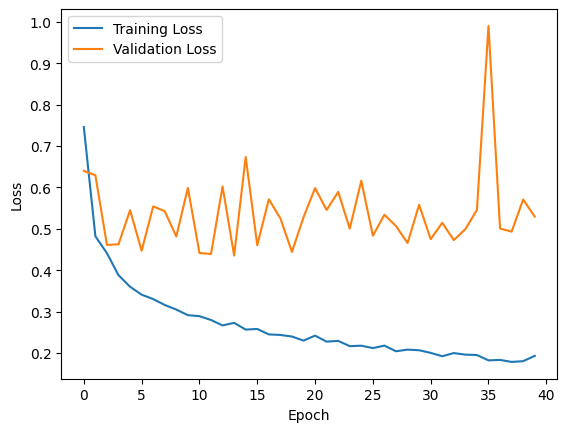

In [25]:
plt.plot(training_losses1, label='Training Loss')
plt.plot(valid_losses1, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

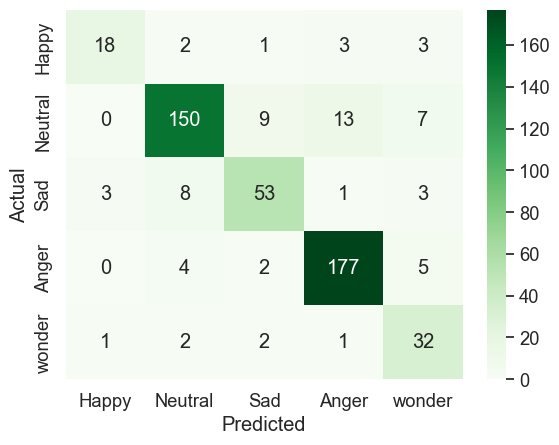

Testing finished with Loss:  0.44 | U_Accuracy:  0.81 | W_Accuracy:  0.86 | Precision:  0.87 | Recall:  0.86 | f1:  0.86
Accuracy per class:
Class 0: 0.6666666666666666
Class 1: 0.8379888268156425
Class 2: 0.7794117647058824
Class 3: 0.9414893617021277
Class 4: 0.8421052631578947


In [26]:
whisper_small.load_state_dict(torch.load('whisper_small_augmented2.bin'))
test(whisper_small, torch.nn.CrossEntropyLoss(), val_loader)

In [17]:
whisper_small.to('cpu')
del whisper_small

# Medium Aug2

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_medium and are newly initialized: ['model.projector.weight', 'model.classifier.weight', 'model.classifier.bias', 'model.projector.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 1269.29 seconds, Training Loss:  0.75, Validation Loss: 0.51, Validation Accuracy:  0.85


Epoch: 2 finished in 1251.76 seconds, Training Loss:  0.47, Validation Loss: 0.41, Validation Accuracy:  0.86


Epoch: 3 finished in 1251.31 seconds, Training Loss:  0.40, Validation Loss: 0.43, Validation Accuracy:  0.85


Epoch: 4 finished in 1250.85 seconds, Training Loss:  0.36, Validation Loss: 0.58, Validation Accuracy:  0.77


...

Epoch: 36 finished in 1250.48 seconds, Training Loss:  0.15, Validation Loss: 0.45, Validation Accuracy:  0.88


Epoch: 37 finished in 1250.97 seconds, Training Loss:  0.16, Validation Loss: 0.45, Validation Accuracy:  0.86


Epoch: 38 finished in 1251.72 seconds, Training Loss:  0.15, Validation Loss: 0.46, Validation Accuracy:  0.85


Epoch: 39 finished in 1250.69 seconds, Training Loss:  0.15, Validation Loss: 0.46, Validation Accuracy:  0.85


Epoch: 40 finished in 1262.08 seconds, Training Loss:  0.15, Validation Loss: 0.46, Validation Accuracy:  0.86
Each epoch took 1250.55 seconds in average.


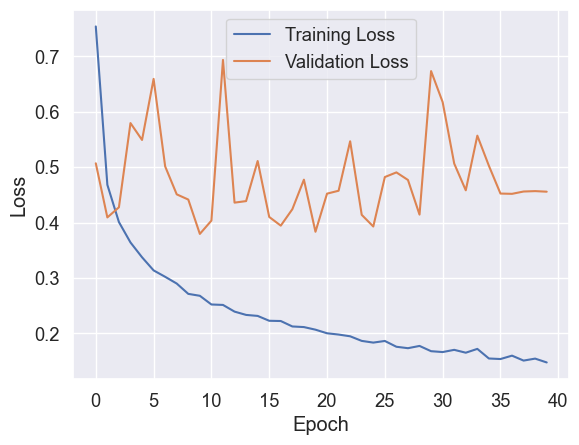

In [79]:
reset_seed(42)
whisper_medium_path = 'whisper_medium'
whisper_medium = WhisperForAudioClassification.from_pretrained(
    whisper_medium_path
)


for param in whisper_medium.parameters():
    param.requires_grad = False

for param in whisper_medium.projector.parameters():
    param.requires_grad = True

whisper_medium.classifier = torch.nn.Linear(256, 5) # Changing the head to fit our data and problem

whisper_medium.to(device)


optimizer = torch.optim.Adam(whisper_medium.parameters(), lr=0.0005)

training_losses2, valid_losses2 = train(whisper_medium, 'whisper_medium_augmented2', optimizer, torch.nn.CrossEntropyLoss(), train_loader, val_loader, patience=40)


plt.plot(training_losses2, label='Training Loss')
plt.plot(valid_losses2, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

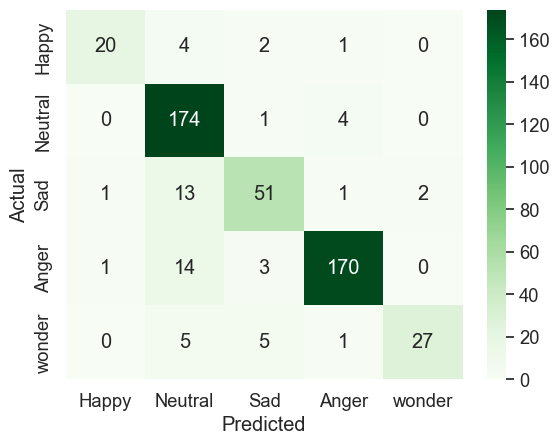

Testing finished with Loss:  0.38 | U_Accuracy:  0.82 | W_Accuracy:  0.88 | Precision:  0.89 | Recall:  0.88 | f1:  0.88
Accuracy per class:
Class 0: 0.7407407407407407
Class 1: 0.9720670391061452
Class 2: 0.75
Class 3: 0.9042553191489362
Class 4: 0.7105263157894737


In [80]:
whisper_medium.load_state_dict(torch.load('whisper_medium_augmented2.bin'))
test(whisper_medium, torch.nn.CrossEntropyLoss(), val_loader)

In [81]:
whisper_medium.to('cpu')
del whisper_medium

In [154]:
em = emotions + augmented_emotions

In [155]:
len(em)

9455

In [156]:
unique, counts = np.unique(em, return_counts=True)

In [157]:
unique

array(['A', 'H', 'N', 'S', 'W'], dtype='<U1')

In [158]:
np.round(counts/counts.sum()*100)

array([20., 19., 20., 21., 20.])

([<matplotlib.patches.Wedge at 0x119fc407160>,
 [Text(0.8814657352439438, 0.6580411518977014, 'Angy'),
  Text(-0.32388979951636043, 1.0512351771935964, 'Happy'),
  Text(-1.097944874068397, 0.06720902846293607, 'Neutral'),
  Text(-0.37997846546296954, -1.0322869590304855, 'Sad'),
  Text(0.8862524240329228, -0.6515801108810555, 'Superise')],
 [Text(0.480799491951242, 0.3589315373987462, '20.4%'),
  Text(-0.17666716337256022, 0.5734010057419616, '18.7%'),
  Text(-0.5988790222191256, 0.036659470070692396, '19.9%'),
  Text(-0.20726098116161973, -0.5630656140166284, '20.9%'),
  Text(0.48341041310886695, -0.35540733320784845, '20.2%')])

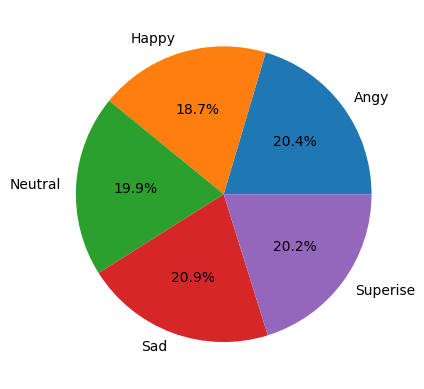

In [159]:
plt.pie(counts, labels=['Angy', 'Happy', 'Neutral', 'Sad', 'Superise'], autopct='%1.1f%%')